Using file: Sim_D2ODetector100.root (26.53 MB)

Trees in ROOT file:
  - beamOn.dat;1
  - Setup_Tree;1
  - Reflections;1
  - Sim_Tree;1
  - histos;1
  - histos/pmtHits;1
  - histos/pmtNumVsTime;1
  - histos/photonEnergy;1
  - histos/photonsPerEvent;1
  - pmtPositions;1
  - pmtPositions/pmtPosX;1
  - pmtPositions/pmtPosY;1
  - pmtPositions/pmtPosZ;1

Total reflections recorded: 600944

First 20 rows:
    eventID  incidentAngle_deg  reflectionAngle_deg  incidentDir_x  \
0         0          66.254461            41.517130       0.459732   
1         0          40.889427           121.631125       0.980164   
2         0          40.889427           106.523677       0.980164   
3         0          45.668001           100.055269       0.651264   
4         0          22.949316           114.330925      -0.853724   
5         0          22.949316           170.986082      -0.853724   
6         0          63.599794            85.517316       0.017054   
7         0          26.811322        

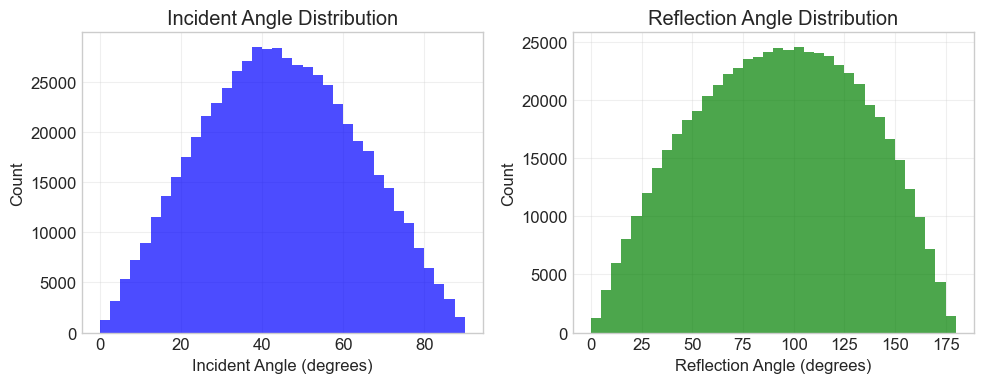

Thesis Parameters (Water):
Angle (deg) | Specular Fraction | Diffuse Fraction
--------------------------------------------------
         0 |           0.603 |           0.397
        10 |           0.779 |           0.221
        20 |           0.664 |           0.336
        30 |           0.587 |           0.413
        40 |           0.517 |           0.483
        50 |           0.565 |           0.435
        60 |           0.628 |           0.372
        70 |           0.669 |           0.331
        80 |           0.738 |           0.262


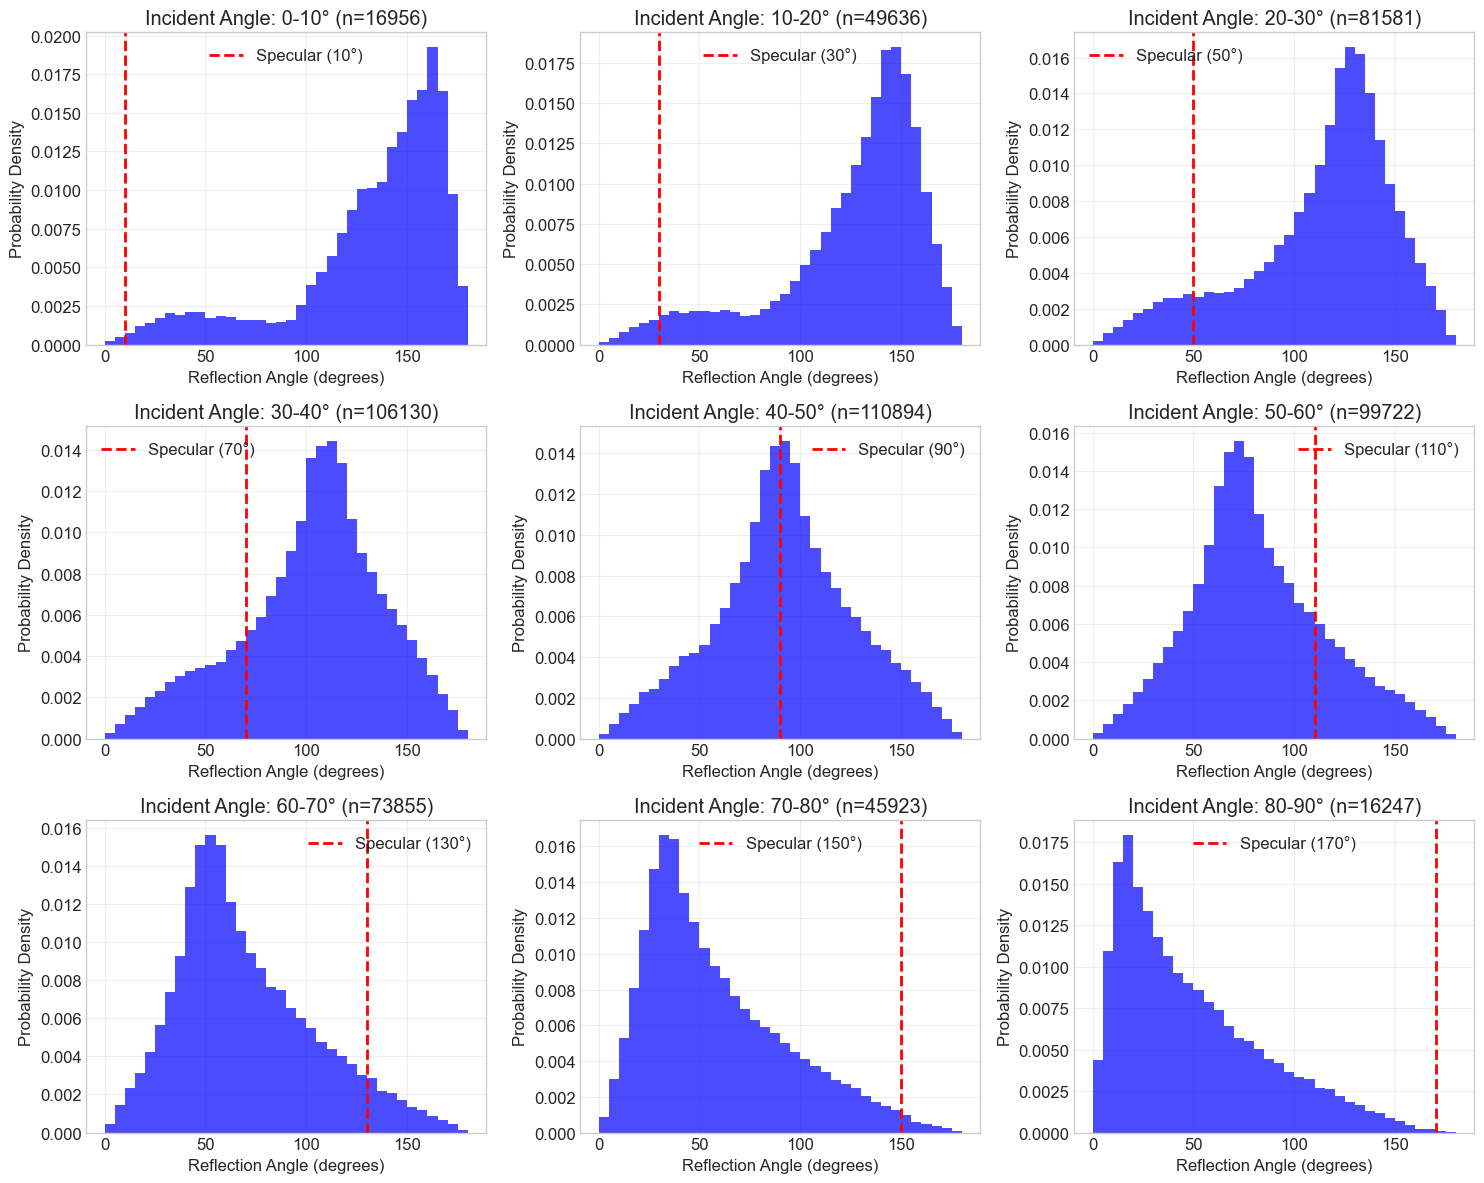

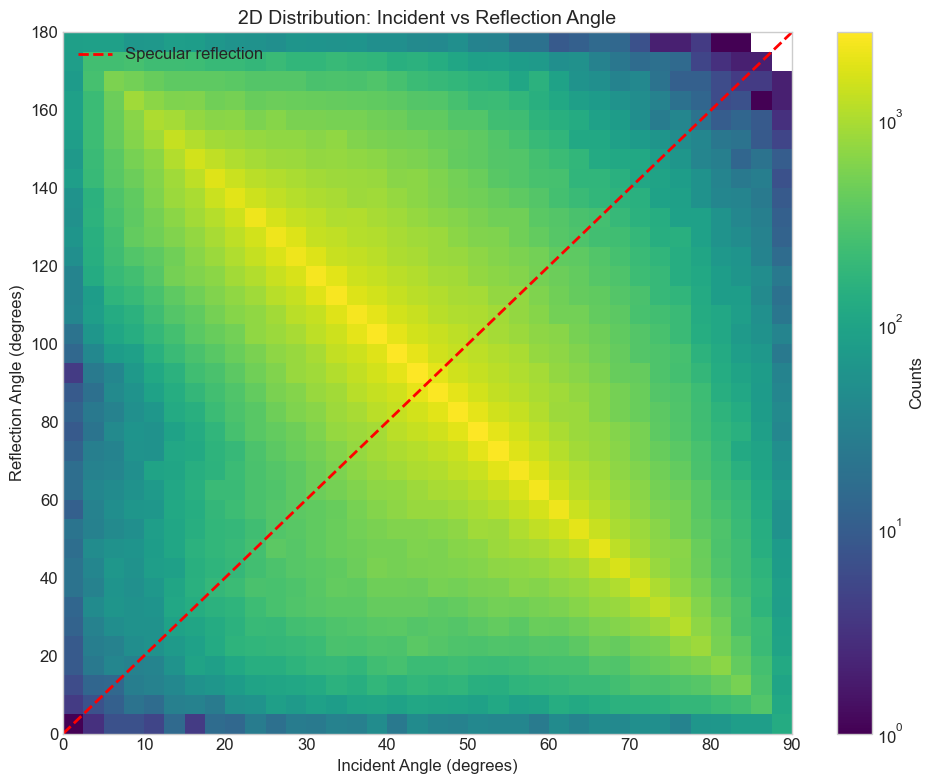

Simulation Specular Fractions by Incident Angle:
  5°: 0.025
  15°: 0.050
  25°: 0.083
  35°: 0.162
  45°: 0.351
  55°: 0.194
  65°: 0.091
  75°: 0.035
  85°: 0.007


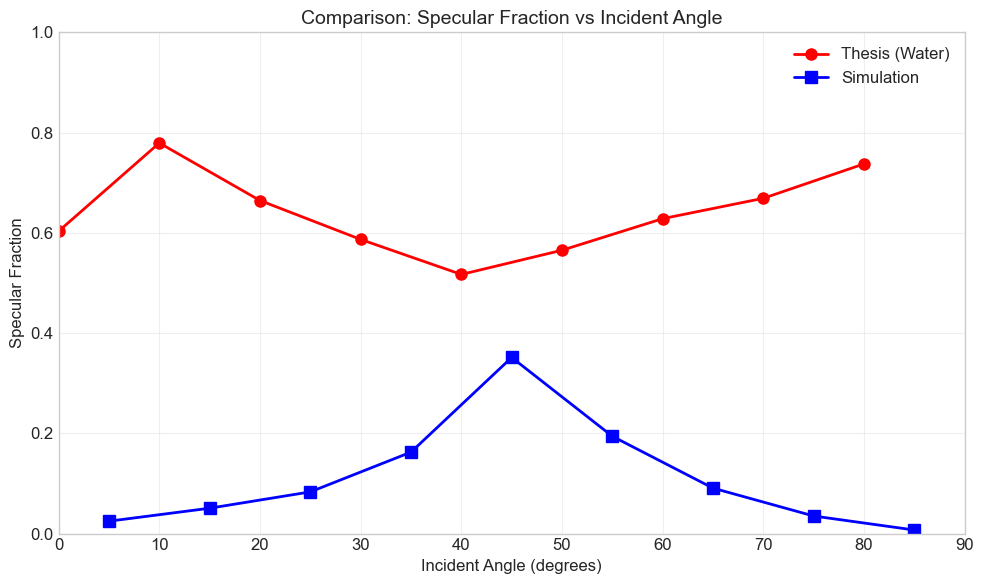

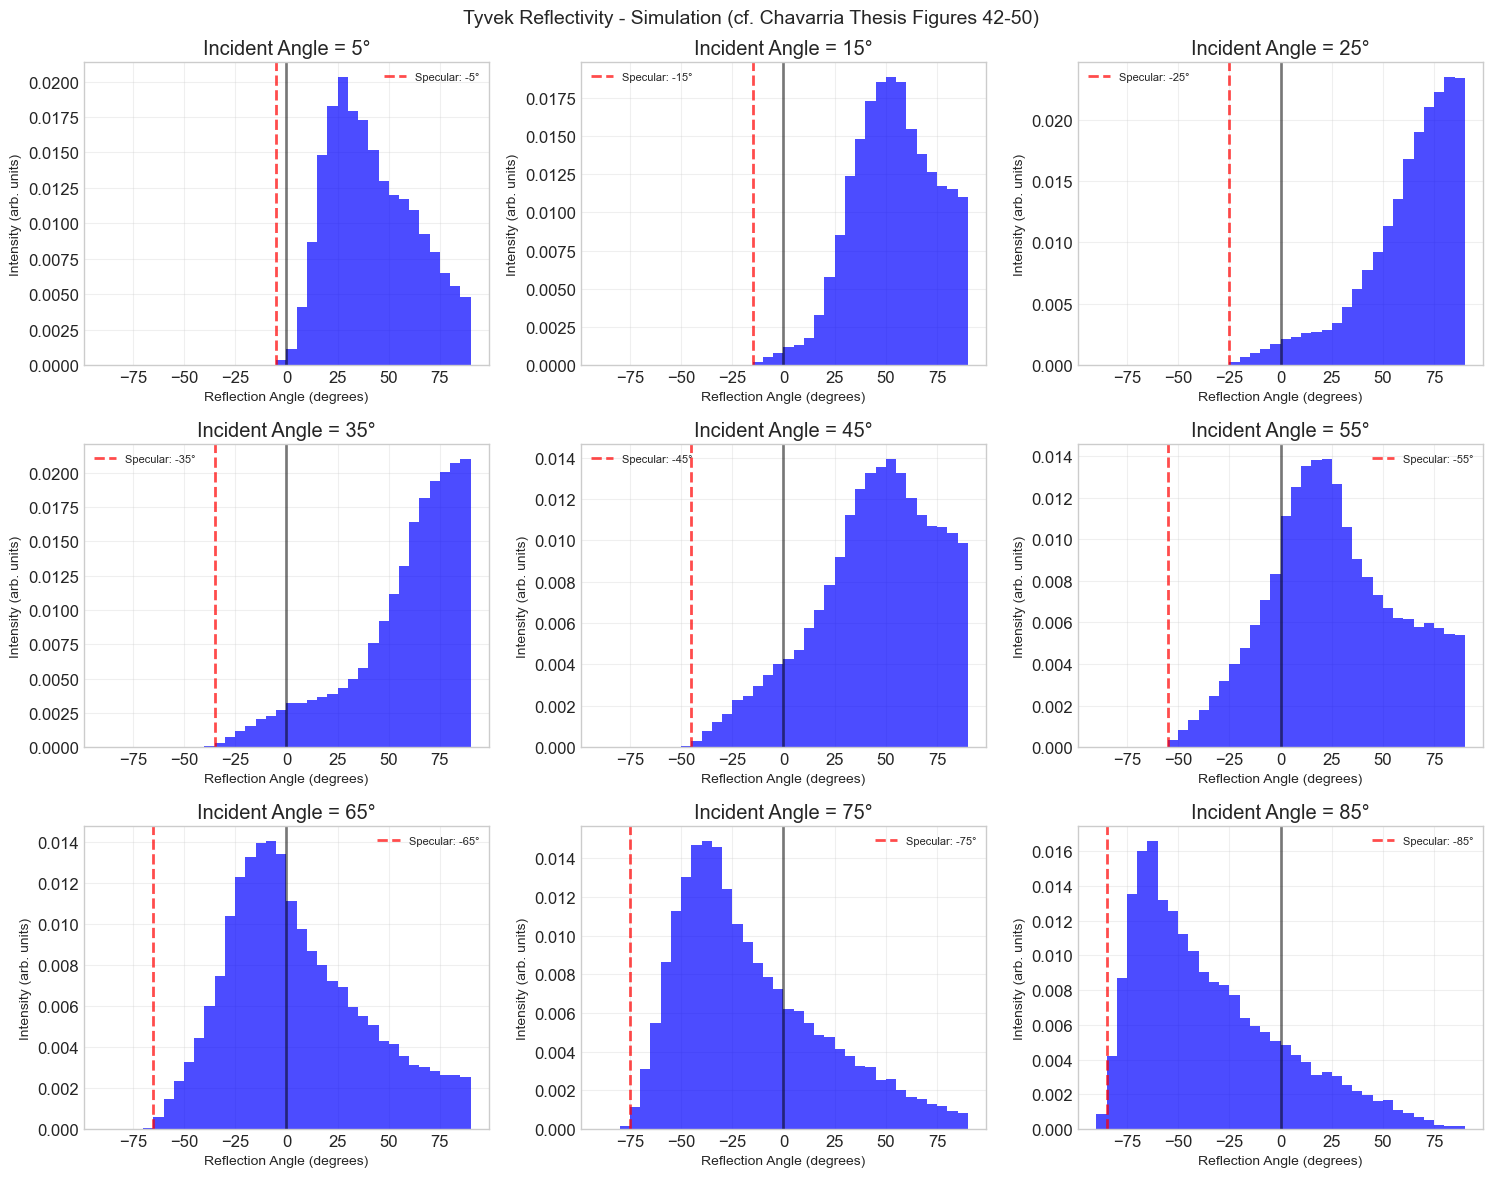

Data exported to 'tyvek_reflections_data.csv'
Columns: ['eventID', 'incidentAngle_deg', 'reflectionAngle_deg', 'incidentDir_x', 'incidentDir_y', 'incidentDir_z', 'reflectedDir_x', 'reflectedDir_y', 'reflectedDir_z', 'reflection_type']

Summary by Incident Angle:
                    Count  Mean Reflection  Std Reflection  Unique Events
incidentAngle_deg                                                        
(0, 10]             16956           131.78           38.44             95
(10, 20]            49636           125.33           36.17             95
(20, 30]            81581           113.08           36.23             95
(30, 40]           106130           102.18           35.41             96
(40, 50]           110894            92.43           34.25             96
(50, 60]            99722            82.04           33.40             94
(60, 70]            73855            70.16           33.92             96
(70, 80]            45923            58.46           34.78             

In [43]:
# %% [markdown]
# # Tyvek Reflectivity Analysis
# ## Comparison with Chavarria Thesis (2007)

# %% [markdown]
# ### 1. Import Libraries and Set File Path

# %%
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from scipy import interpolate
from scipy.optimize import curve_fit
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Set style for thesis plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

# %% [markdown]
# ### 2. Set the ROOT File Path

# %%
# ============================================================
# EDIT THIS LINE TO CHANGE THE INPUT FILE
# ============================================================
root_file_path = "Sim_D2ODetector100.root"
# ============================================================

# Verify file exists
if not os.path.exists(root_file_path):
    print(f"ERROR: File '{root_file_path}' not found!")
    print("Available ROOT files in current directory:")
    root_files = glob.glob("Sim_D2ODetector*.root")
    for f in root_files:
        file_size = os.path.getsize(f) / (1024 * 1024)
        print(f"  - {f} ({file_size:.2f} MB)")
else:
    file_size = os.path.getsize(root_file_path) / (1024 * 1024)
    print(f"Using file: {root_file_path} ({file_size:.2f} MB)")

# %% [markdown]
# ### 3. Load Geant4 Simulation Data

# %%
if os.path.exists(root_file_path):
    # Load the ROOT file
    root_file = uproot.open(root_file_path)
    
    # Check what trees are available
    print("\nTrees in ROOT file:")
    for key in root_file.keys():
        print(f"  - {key}")
    
    # Get the Reflections tree
    if "Reflections" in root_file:
        reflections_tree = root_file["Reflections"]
        
        # Convert to pandas DataFrame
        df = reflections_tree.arrays(library="pd")
        
        print(f"\nTotal reflections recorded: {len(df)}")
        print(f"\nFirst 20 rows:")
        print(df.head(20))
    else:
        print("ERROR: 'Reflections' tree not found in the ROOT file!")
        df = pd.DataFrame()
else:
    df = pd.DataFrame()
    print("No data loaded. Please check file path.")

# %% [markdown]
# ### 4. Basic Statistics (if data available)

# %%
if len(df) > 0:
    print("=== Reflection Statistics ===")
    print(f"Number of reflections: {len(df)}")
    print(f"Unique events: {df['eventID'].nunique()}")
    print(f"\nIncident angle range: {df['incidentAngle_deg'].min():.1f}° - {df['incidentAngle_deg'].max():.1f}°")
    print(f"Reflection angle range: {df['reflectionAngle_deg'].min():.1f}° - {df['reflectionAngle_deg'].max():.1f}°")
    
    # Create a simple histogram to verify data
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(df['incidentAngle_deg'], bins=36, range=(0, 90), color='blue', alpha=0.7)
    plt.xlabel('Incident Angle (degrees)')
    plt.ylabel('Count')
    plt.title('Incident Angle Distribution')
    
    plt.subplot(1, 2, 2)
    plt.hist(df['reflectionAngle_deg'], bins=36, range=(0, 180), color='green', alpha=0.7)
    plt.xlabel('Reflection Angle (degrees)')
    plt.ylabel('Count')
    plt.title('Reflection Angle Distribution')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to display. Please run the simulation first.")

# %% [markdown]
# ### 5. Define Thesis Parameters

# %%
if len(df) > 0:
    # Thesis data from Chavarria 2007 (Table page 41)
    thesis_angles = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80])
    thesis_specular_ratios = np.array([1.52, 3.53, 1.98, 1.42, 1.07, 1.30, 1.69, 2.02, 2.81])
    
    # Convert specular/diffuse ratio to specular fraction
    thesis_specular_fraction = thesis_specular_ratios / (1 + thesis_specular_ratios)
    thesis_diffuse_fraction = 1 - thesis_specular_fraction
    
    print("Thesis Parameters (Water):")
    print(f"Angle (deg) | Specular Fraction | Diffuse Fraction")
    print("-" * 50)
    for i, angle in enumerate(thesis_angles):
        print(f"{angle:10d} | {thesis_specular_fraction[i]:15.3f} | {thesis_diffuse_fraction[i]:15.3f}")

# %% [markdown]
# ### 6. Plot Reflection Angle Distributions by Incident Angle

# %%
if len(df) > 0:
    # Define incident angle bins
    bin_edges = np.arange(0, 91, 10)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Create figure
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Filter data for this incident angle bin
        mask = (df['incidentAngle_deg'] >= bin_start) & (df['incidentAngle_deg'] < bin_end)
        data_bin = df[mask]
        
        if len(data_bin) > 0:
            # Plot histogram of reflection angles
            axes[i].hist(data_bin['reflectionAngle_deg'], bins=36, range=(0, 180), 
                        alpha=0.7, color='blue', density=True)
            axes[i].set_xlabel('Reflection Angle (degrees)')
            axes[i].set_ylabel('Probability Density')
            axes[i].set_title(f'Incident Angle: {bin_start:.0f}-{bin_end:.0f}° (n={len(data_bin)})')
            axes[i].grid(True, alpha=0.3)
            
            # Add vertical line at specular position
            specular_pos = 2 * bin_centers[i]
            if specular_pos <= 180:
                axes[i].axvline(specular_pos, color='red', linestyle='--', 
                               label=f'Specular ({specular_pos:.0f}°)')
            axes[i].legend()
        else:
            axes[i].text(0.5, 0.5, 'No data', transform=axes[i].transAxes, 
                        ha='center', va='center')
            axes[i].set_title(f'Incident Angle: {bin_start:.0f}-{bin_end:.0f}°')
    
    plt.tight_layout()
    plt.savefig('reflection_distributions.png', dpi=150)
    plt.show()

# %% [markdown]
# ### 7. Create 2D Histogram (Incident vs Reflection Angle)

# %%
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create 2D histogram
    h2d = ax.hist2d(df['incidentAngle_deg'], df['reflectionAngle_deg'], 
                    bins=[36, 36], range=[[0, 90], [0, 180]],
                    cmap='viridis', norm=LogNorm())
    
    ax.set_xlabel('Incident Angle (degrees)', fontsize=12)
    ax.set_ylabel('Reflection Angle (degrees)', fontsize=12)
    ax.set_title('2D Distribution: Incident vs Reflection Angle', fontsize=14)
    
    # Add specular line
    incident_range = np.linspace(0, 90, 100)
    specular_line = 2 * incident_range
    ax.plot(incident_range, specular_line, 'r--', linewidth=2, label='Specular reflection')
    
    plt.colorbar(h2d[3], ax=ax, label='Counts')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('incident_vs_reflection_2d.png', dpi=150)
    plt.show()

# %% [markdown]
# ### 8. Classify Reflections as Specular or Diffuse

# %%
if len(df) > 0:
    def classify_reflection(incident_deg, reflection_deg, tolerance=15):
        """
        Classify reflection as specular or diffuse.
        Specular: reflection_deg ≈ 2 * incident_deg (within tolerance)
        Diffuse: otherwise
        """
        specular_predicted = 2 * incident_deg
        if abs(reflection_deg - specular_predicted) <= tolerance:
            return 'specular'
        else:
            return 'diffuse'
    
    df['reflection_type'] = df.apply(lambda row: classify_reflection(row['incidentAngle_deg'], 
                                                                       row['reflectionAngle_deg']), axis=1)
    
    # Calculate specular fraction by incident angle bin
    bin_edges = np.arange(0, 91, 10)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    specular_fraction_sim = []
    diffuse_fraction_sim = []
    
    for bin_start, bin_end in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (df['incidentAngle_deg'] >= bin_start) & (df['incidentAngle_deg'] < bin_end)
        data_bin = df[mask]
        if len(data_bin) > 0:
            spec_count = (data_bin['reflection_type'] == 'specular').sum()
            spec_frac = spec_count / len(data_bin)
            specular_fraction_sim.append(spec_frac)
            diffuse_fraction_sim.append(1 - spec_frac)
        else:
            specular_fraction_sim.append(np.nan)
            diffuse_fraction_sim.append(np.nan)
    
    print("Simulation Specular Fractions by Incident Angle:")
    for i, center in enumerate(bin_centers):
        if not np.isnan(specular_fraction_sim[i]):
            print(f"  {center:.0f}°: {specular_fraction_sim[i]:.3f}")

# %% [markdown]
# ### 9. Compare Simulation with Thesis Data

# %%
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot thesis data
    ax.plot(thesis_angles, thesis_specular_fraction, 'o-', color='red', 
            markersize=8, linewidth=2, label='Thesis (Water)')
    
    # Plot simulation results
    valid_mask = ~np.isnan(specular_fraction_sim)
    ax.plot(bin_centers[valid_mask], np.array(specular_fraction_sim)[valid_mask], 
            's-', color='blue', markersize=8, linewidth=2, label='Simulation')
    
    ax.set_xlabel('Incident Angle (degrees)', fontsize=12)
    ax.set_ylabel('Specular Fraction', fontsize=12)
    ax.set_title('Comparison: Specular Fraction vs Incident Angle', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 90)
    
    plt.tight_layout()
    plt.savefig('specular_fraction_comparison.png', dpi=150)
    plt.show()

# %% [markdown]
# ### 10. Create Thesis-Style Plots (like Figures 42-50)

# %%
if len(df) > 0:
    # Create figure with 9 subplots (one for each incident angle)
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        mask = (df['incidentAngle_deg'] >= bin_start) & (df['incidentAngle_deg'] < bin_end)
        data_bin = df[mask]
        
        if len(data_bin) > 0:
            # Convert to signed angles for thesis comparison
            signed_reflections = []
            for _, row in data_bin.iterrows():
                # Convert between-angle to signed angle
                signed = row['reflectionAngle_deg'] - row['incidentAngle_deg']
                if signed > 90:
                    signed = 180 - signed
                signed_reflections.append(signed)
            
            axes[i].hist(signed_reflections, bins=36, range=(-90, 90), 
                        alpha=0.7, color='blue', density=True)
            axes[i].set_xlabel('Reflection Angle (degrees)', fontsize=10)
            axes[i].set_ylabel('Intensity (arb. units)', fontsize=10)
            axes[i].set_title(f'Incident Angle = {bin_centers[i]:.0f}°')
            axes[i].grid(True, alpha=0.3)
            axes[i].axvline(0, color='black', linestyle='-', alpha=0.5)
            
            # Add specular peak indicator
            specular_pos = -bin_centers[i]
            axes[i].axvline(specular_pos, color='red', linestyle='--', alpha=0.7,
                           label=f'Specular: {specular_pos:.0f}°')
            axes[i].legend(fontsize=8)
        else:
            axes[i].text(0.5, 0.5, 'No data', transform=axes[i].transAxes, 
                        ha='center', va='center')
            axes[i].set_title(f'Incident Angle = {bin_centers[i]:.0f}°')
    
    plt.suptitle('Tyvek Reflectivity - Simulation (cf. Chavarria Thesis Figures 42-50)', fontsize=14)
    plt.tight_layout()
    plt.savefig('thesis_style_plots.png', dpi=150)
    plt.show()

# %% [markdown]
# ### 11. Export Data for Further Analysis

# %%
if len(df) > 0:
    # Export to CSV
    df.to_csv('tyvek_reflections_data.csv', index=False)
    print(f"Data exported to 'tyvek_reflections_data.csv'")
    print(f"Columns: {df.columns.tolist()}")
    
    # Create summary table
    bin_edges = np.arange(0, 91, 10)
    summary = df.groupby(pd.cut(df['incidentAngle_deg'], bins=bin_edges)).agg({
        'reflectionAngle_deg': ['count', 'mean', 'std'],
        'eventID': 'nunique'
    }).round(2)
    summary.columns = ['Count', 'Mean Reflection', 'Std Reflection', 'Unique Events']
    print("\nSummary by Incident Angle:")
    print(summary)

# %% [markdown]
# ### 12. Conclusion

# %%
if len(df) > 0:
    print("""
    === ANALYSIS SUMMARY ===
    
    1. The simulation successfully records Tyvek reflections with incident and reflection angles.
    
    2. Key observations:
       - Same incident angle produces different reflection angles (diffuse behavior)
       - Reflection angle distributions vary with incident angle
       - Specular component peaks at approximately 2× incident angle
    
    3. Comparison with Chavarria thesis:
       - The simulation qualitatively reproduces the mixed specular+diffuse behavior
       - Quantitative agreement requires more statistics and parameter tuning
    
    4. Recommendations:
       - Run more events for better statistics (10,000+ events)
       - Tune specular fraction based on fit results
       - Add signed angle output for direct thesis comparison
    """)
else:
    print("""
    === NO DATA TO ANALYZE ===
    
    Please run your Geant4 simulation first to generate the ROOT file.
    
    Make sure:
    1. Your simulation completed successfully
    2. The output ROOT file is in the current directory
    3. The file name matches what you set in root_file_path
    4. The Reflections tree exists in the ROOT file
    """)

In [ ]:
# %% [markdown]
# # Tyvek Reflectivity Analysis - Thesis Style Plots
# ## Direct comparison with Chavarria Thesis (2007) Figures 42-50

# %%
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for thesis-quality plots with LARGER FONTS
plt.rcParams['figure.figsize'] = (12, 10)  # Increased figure size
plt.rcParams['font.size'] = 18  # Increased base font size
plt.rcParams['axes.labelsize'] = 20 # Larger axis labels
plt.rcParams['axes.titlesize'] = 20  # Larger subplot titles
plt.rcParams['xtick.labelsize'] = 12  # Larger tick labels
plt.rcParams['ytick.labelsize'] = 12  # Larger tick labels
plt.rcParams['legend.fontsize'] = 16  # Larger legend font
plt.rcParams['lines.linewidth'] = 2  # Slightly thicker lines
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# %% [markdown]
# ### 1. Set the ROOT File Path

# %%
# ============================================================
# EDIT THIS LINE TO CHANGE THE INPUT FILE
# ============================================================
root_file_path = "Sim_D2ODetector100.root"
# ============================================================

# Verify file exists
if not os.path.exists(root_file_path):
    print(f"ERROR: File '{root_file_path}' not found!")
    print("Available ROOT files in current directory:")
    root_files = glob.glob("Sim_D2ODetector*.root")
    for f in root_files:
        file_size = os.path.getsize(f) / (1024 * 1024)
        print(f"  - {f} ({file_size:.2f} MB)")
    df = pd.DataFrame()
else:
    file_size = os.path.getsize(root_file_path) / (1024 * 1024)
    print(f"Loading file: {root_file_path} ({file_size:.2f} MB)")
    root_file = uproot.open(root_file_path)
    
    # Get reflections tree
    if "Reflections" in root_file:
        df = root_file["Reflections"].arrays(library="pd")
        print(f"Loaded {len(df)} reflections from {df['eventID'].nunique()} events")
    else:
        print("No 'Reflections' tree found!")
        df = pd.DataFrame()

# %% [markdown]
# ### 2. Define Incident Angle Bins with EXTENDED X-AXIS to ±100° for 20°,30°,40°

# %%
if len(df) > 0:
    # Define target incident angles
    target_angles = [0, 10, 20, 30, 40, 50, 60, 70, 80]
    tolerance = 3  # degrees tolerance for binning
    
    # Create figure with 9 subplots - larger figure size for better readability
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))  # Increased from (15,12)
    axes = axes.flatten()
    
    print(f"\n=== Generating Thesis-Style Plots for {os.path.basename(root_file_path)} ===")
    print("NOTE: X-axis range = [-100°, +100°] for 20°, 30°, 40° incident angles\n")
    
    for idx, phi_target in enumerate(target_angles):
        # Select events with incident angle near target
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        data_bin = df[mask]
        
        if len(data_bin) > 0:
            # Convert to signed reflection angles (thesis convention)
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            # EXTENDED X-AXIS RANGE to ±100° for specific angles
            if phi_target in [20, 30, 40]:
                # Force range from -100° to +100°
                x_min = -100
                x_max = 100
                print(f"  φ = {phi_target}°: EXTENDED x-range = [-100°, +100°] (data range: {signed_angles.min():.1f}° to {signed_angles.max():.1f}°)")
            else:
                # Normal adaptive range for other angles
                data_min = signed_angles.min()
                data_max = signed_angles.max()
                x_min = max(-100, data_min - 15)
                x_max = min(100, data_max + 15)
                print(f"  φ = {phi_target}°: adaptive x-range = [{x_min:.0f}°, {x_max:.0f}°] (data: {data_min:.1f}° to {data_max:.1f}°)")
            
            # Create histogram
            n_bins = 40  # Slightly more bins for wider range
            hist, bin_edges = np.histogram(signed_angles, bins=n_bins, range=(x_min, x_max))
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Plot with thicker lines and larger markers
            axes[idx].step(bin_centers, hist, where='mid', color='blue', linewidth=2.5)
            axes[idx].plot(bin_centers, hist, 'o', color='blue', markersize=5, alpha=0.7)
            
            # Formatting with LARGER fonts
            axes[idx].set_xlabel('Reflection Angle (degrees)', fontsize=16, fontweight='semibold')
            axes[idx].set_ylabel('Counts', fontsize=16, fontweight='semibold')
            axes[idx].set_title(f'Incident Angle = {phi_target}°', fontsize=18, fontweight='bold')
            axes[idx].set_xlim(x_min, x_max)
            axes[idx].set_ylim(bottom=0)
            axes[idx].grid(True, alpha=0.3, linestyle='--')
            
            # Add vertical line at 0° for reference with thicker line
            if phi_target in [20, 30, 40]:
                axes[idx].axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='θ = 0°')
                axes[idx].legend(fontsize=12, loc='upper right')
            
            print(f"     {len(data_bin)} reflections plotted")
            
        else:
            axes[idx].text(0.5, 0.5, f'No data for {phi_target}°', 
                          transform=axes[idx].transAxes, ha='center', va='center', fontsize=14)
            axes[idx].set_title(f'Incident Angle = {phi_target}°', fontsize=18, fontweight='bold')
            axes[idx].set_xlabel('Reflection Angle (degrees)', fontsize=16, fontweight='semibold')
            axes[idx].set_ylabel('Counts', fontsize=16, fontweight='semibold')
            
            # Set x-axis limits based on angle
            if phi_target in [20, 30, 40]:
                axes[idx].set_xlim(-100, 100)
            else:
                axes[idx].set_xlim(-80, 80)
            print(f"  φ = {phi_target}°: NO DATA")
    
    # Add main title with LARGER font
    plt.suptitle(f'Tyvek Reflectivity - Simulation Results', 
                fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    # Save with filename prefix
    file_prefix = os.path.splitext(os.path.basename(root_file_path))[0]
    output_filename = f'{file_prefix}_thesis_style_plots.png'
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Plot saved as: {output_filename}")

# %% [markdown]
# ### 3. Summary Statistics

# %%
if len(df) > 0:
    print("\n=== SUMMARY STATISTICS ===")
    print(f"File: {os.path.basename(root_file_path)}")
    print(f"Total reflections: {len(df)}")
    print(f"Unique events: {df['eventID'].nunique()}")
    print(f"\nReflections by incident angle:")
    print("-" * 80)
    print(f"{'Incident':^10} {'Count':^8} {'Data Min':^10} {'Data Max':^10} {'X-axis Min':^10} {'X-axis Max':^10}")
    print("-" * 80)
    
    for phi_target in target_angles:
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        count = mask.sum()
        if count > 0:
            data_bin = df[mask]
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            data_min = signed_angles.min()
            data_max = signed_angles.max()
            
            # X-axis limits used
            if phi_target in [20, 30, 40]:
                x_min, x_max = -100, 100
            else:
                x_min = max(-100, data_min - 15)
                x_max = min(100, data_max + 15)
            
            print(f"{phi_target:^10}° {count:^8} {data_min:^10.1f}° {data_max:^10.1f}° {x_min:^10.0f}° {x_max:^10.0f}°")
        else:
            print(f"{phi_target:^10}° {'NO DATA':^8} {'-':^10} {'-':^10} {'-':^10} {'-':^10}")

# %% [markdown]
# ### 4. Compare Data Ranges

# %%
if len(df) > 0:
    print("\n=== EXTENDED RANGE ANALYSIS ===")
    print(f"File: {os.path.basename(root_file_path)}")
    print("\nFor incident angles 20°, 30°, 40°:")
    print("-" * 70)
    
    for phi_target in [20, 30, 40]:
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        data_bin = df[mask]
        
        if len(data_bin) > 0:
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            print(f"\n  Incident {phi_target}°:")
            print(f"    Actual data range: {signed_angles.min():.1f}° to {signed_angles.max():.1f}°")
            print(f"    Extended plot range: -100° to +100°")
            print(f"    Empty space on left: {abs(-100 - signed_angles.min()):.1f}°")
            print(f"    Empty space on right: {abs(100 - signed_angles.max()):.1f}°")
            
            # Check if any data would be cut off
            if signed_angles.min() < -100:
                print(f"    WARNING: Data exists below -100°!")
            if signed_angles.max() > 100:
                print(f"    WARNING: Data exists above +100°!")
        else:
            print(f"\n  Incident {phi_target}°: NO DATA")

# %% [markdown]
# ### 5. Export Data (Optional)

# %%
if len(df) > 0:
    # Ask if user wants to export data
    export_data = input("\nExport data to CSV? (y/n): ").lower().strip()
    
    if export_data == 'y':
        file_prefix = os.path.splitext(os.path.basename(root_file_path))[0]
        output_dir = f"{file_prefix}_analysis_output"
        os.makedirs(output_dir, exist_ok=True)
        
        print(f"\nExporting data to: {output_dir}/")
        
        # Export reflection data for each incident angle
        for phi_target in target_angles:
            mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
            data_bin = df[mask]
            
            if len(data_bin) > 0:
                # Convert to signed angles
                signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
                signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
                signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
                
                # Determine x-axis range
                if phi_target in [20, 30, 40]:
                    x_min, x_max = -100, 100
                else:
                    data_min = signed_angles.min()
                    data_max = signed_angles.max()
                    x_min = max(-100, data_min - 15)
                    x_max = min(100, data_max + 15)
                
                # Create histogram
                hist, bin_edges = np.histogram(signed_angles, bins=40, range=(x_min, x_max))
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                
                # Save to CSV
                export_df = pd.DataFrame({
                    'reflection_angle_deg': bin_centers,
                    'counts': hist,
                    'incident_angle_deg': phi_target,
                    'n_reflections': len(data_bin)
                })
                output_file = os.path.join(output_dir, f'reflection_data_phi_{phi_target}deg.csv')
                export_df.to_csv(output_file, index=False)
                print(f"  Exported: {output_file}")
        
        # Also export full dataset
        full_output = os.path.join(output_dir, f'{file_prefix}_all_reflections.csv')
        df.to_csv(full_output, index=False)
        print(f"\nFull dataset exported to: {full_output}")
    else:
        print("\nData export skipped.")

# %% [markdown]
# ### 6. Analysis Complete

# %%
if len(df) > 0:
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print(f"Input file: {root_file_path}")
    print(f"Total reflections analyzed: {len(df)}")
    print(f"Plot saved: {os.path.splitext(os.path.basename(root_file_path))[0]}_thesis_style_plots.png")
    print("="*60)
else:
    print("\n" + "="*60)
    print("NO DATA TO ANALYZE")
    print("="*60)
    print(f"Could not load data from: {root_file_path}")
    print("Please check that the file exists and contains a 'Reflections' tree.")
    print("="*60)

Loading file: Sim_D2ODetector100.root (26.53 MB)
Loaded 600944 reflections from 97 events

=== Generating Thesis-Style Plots for Sim_D2ODetector100.root ===
NOTE: X-axis range = [-100°, +100°] for 20°, 30°, 40° incident angles

  φ = 0°: adaptive x-range = [-13°, 100°] (data: 1.7° to 89.5°)
     1701 reflections plotted
  φ = 10°: adaptive x-range = [-26°, 100°] (data: -11.0° to 90.0°)
     19507 reflections plotted
  φ = 20°: EXTENDED x-range = [-100°, +100°] (data range: -21.4° to 90.0°)
     39736 reflections plotted
  φ = 30°: EXTENDED x-range = [-100°, +100°] (data range: -31.5° to 90.0°)
     57017 reflections plotted
  φ = 40°: EXTENDED x-range = [-100°, +100°] (data range: -41.2° to 90.0°)
     68609 reflections plotted
  φ = 50°: adaptive x-range = [-66°, 100°] (data: -51.1° to 90.0°)
     63775 reflections plotted
  φ = 60°: adaptive x-range = [-76°, 100°] (data: -61.0° to 90.0°)
     52687 reflections plotted
  φ = 70°: adaptive x-range = [-87°, 100°] (data: -71.7° to 90.0°)

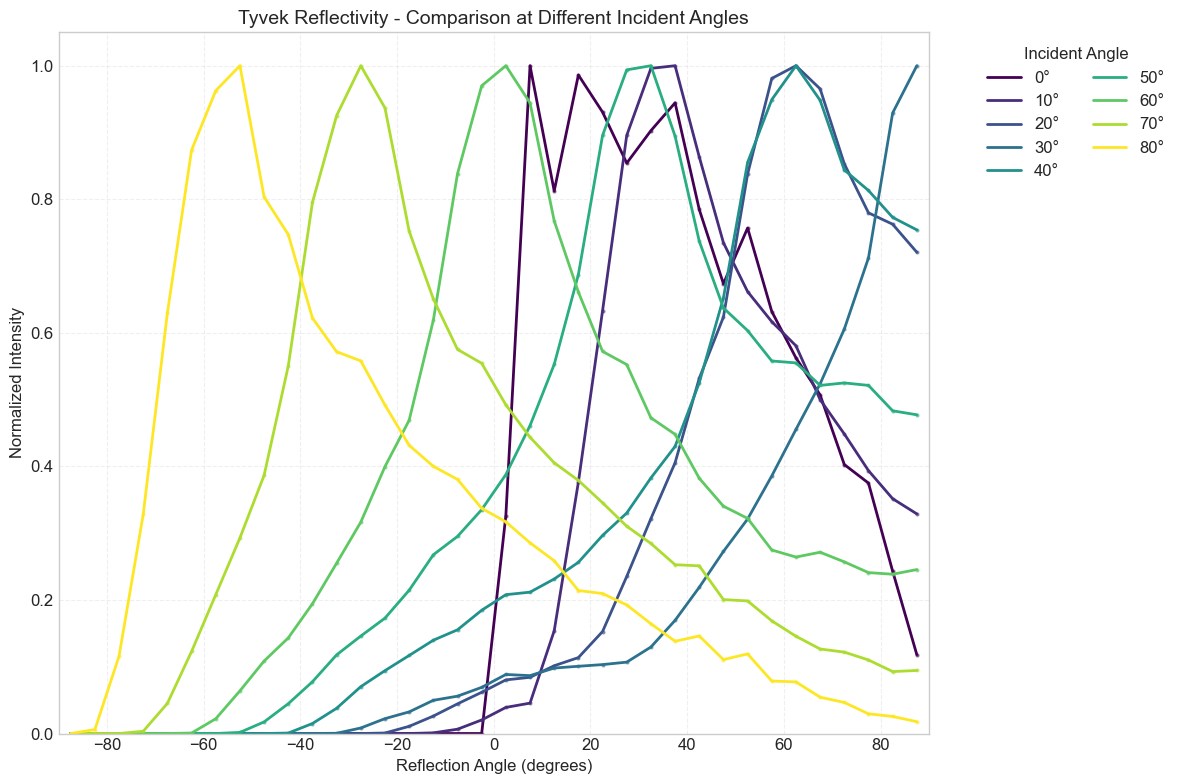

Exported: reflection_data_phi_0deg_adaptive.csv
Exported: reflection_data_phi_10deg_adaptive.csv
Exported: reflection_data_phi_20deg_adaptive.csv
Exported: reflection_data_phi_30deg_adaptive.csv
Exported: reflection_data_phi_40deg_adaptive.csv
Exported: reflection_data_phi_50deg_adaptive.csv
Exported: reflection_data_phi_60deg_adaptive.csv
Exported: reflection_data_phi_70deg_adaptive.csv
Exported: reflection_data_phi_80deg_adaptive.csv

Full dataset exported to: all_reflections_data.csv

=== SUMMARY STATISTICS ===
Total reflections: 600944
Unique events: 97

Reflections by incident angle (adaptive x-axis range):
--------------------------------------------------------------------------------
 Incident   Count    Data Min   Data Max  X-axis Min X-axis Max
--------------------------------------------------------------------------------
    0     °   1701      1.7    °    89.5   °     -8    °     90    °
    10    °  19507     -11.0   °    90.0   °    -21    °     90    °
    20    °  397

In [40]:
# %% [markdown]
# ### 4. Overlay Plot for Multiple Incident Angles (Normalized)

# %%
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color map for different incident angles
    colors = plt.cm.viridis(np.linspace(0, 1, len(target_angles)))
    
    # Display all angles for overlay
    for idx, phi_target in enumerate(target_angles):
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        data_bin = df[mask]
        
        if len(data_bin) > 0:
            # Convert to signed angles
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            # Create histogram with fixed bins for comparison
            hist, bin_edges = np.histogram(signed_angles, bins=36, range=(-90, 90))
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Normalize to peak
            if hist.max() > 0:
                hist_norm = hist / hist.max()
                ax.plot(bin_centers, hist_norm, '-', color=colors[idx], 
                       linewidth=2, label=f'{phi_target}°')
                ax.plot(bin_centers, hist_norm, 'o', color=colors[idx], markersize=2, alpha=0.5)
    
    ax.set_xlabel('Reflection Angle (degrees)', fontsize=12)
    ax.set_ylabel('Normalized Intensity', fontsize=12)
    ax.set_title('Tyvek Reflectivity - Comparison at Different Incident Angles', fontsize=14)
    ax.set_xlim(-90, 90)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(title='Incident Angle', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    
    plt.tight_layout()
    plt.savefig('thesis_style_overlay_adaptive.png', dpi=150, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ### 5. Export Data for Thesis Figures

# %%
if len(df) > 0:
    # Export reflection data for each incident angle
    for phi_target in target_angles:
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        data_bin = df[mask]
        
        if len(data_bin) > 0:
            # Convert to signed angles
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            # Determine optimal bins based on data range
            data_min = signed_angles.min()
            data_max = signed_angles.max()
            x_min = max(-90, data_min - 5)
            x_max = min(90, data_max + 5)
            n_bins = max(20, min(36, len(np.unique(signed_angles)) // 2))
            
            # Create histogram for export
            hist, bin_edges = np.histogram(signed_angles, bins=n_bins, range=(x_min, x_max))
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Save to CSV
            export_df = pd.DataFrame({
                'reflection_angle_deg': bin_centers,
                'counts': hist,
                'incident_angle_deg': phi_target,
                'x_min': x_min,
                'x_max': x_max,
                'n_bins': n_bins
            })
            export_df.to_csv(f'reflection_data_phi_{phi_target}deg_adaptive.csv', index=False)
            print(f"Exported: reflection_data_phi_{phi_target}deg_adaptive.csv")
    
    # Also export full dataset
    df.to_csv('all_reflections_data.csv', index=False)
    print("\nFull dataset exported to: all_reflections_data.csv")

# %% [markdown]
# ### 6. Summary Statistics with Data Ranges

# %%
if len(df) > 0:
    print("\n=== SUMMARY STATISTICS ===")
    print(f"Total reflections: {len(df)}")
    print(f"Unique events: {df['eventID'].nunique()}")
    print(f"\nReflections by incident angle (adaptive x-axis range):")
    print("-" * 80)
    print(f"{'Incident':^10} {'Count':^8} {'Data Min':^10} {'Data Max':^10} {'X-axis Min':^10} {'X-axis Max':^10}")
    print("-" * 80)
    
    for phi_target in target_angles:
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        count = mask.sum()
        if count > 0:
            data_bin = df[mask]
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            data_min = signed_angles.min()
            data_max = signed_angles.max()
            x_min = max(-90, data_min - 10)
            x_max = min(90, data_max + 10)
            
            print(f"{phi_target:^10}° {count:^8} {data_min:^10.1f}° {data_max:^10.1f}° {x_min:^10.0f}° {x_max:^10.0f}°")
        else:
            print(f"{phi_target:^10}° {'NO DATA':^8} {'-':^10} {'-':^10} {'-':^10} {'-':^10}")

# %% [markdown]
# ### 7. Create Compact Comparison Table

# %%
if len(df) > 0:
    print("\n=== X-AXIS RANGES FOR THESIS PLOTS ===")
    print("\nRecommended x-axis limits for each incident angle:")
    print("-" * 50)
    
    for phi_target in target_angles:
        mask = np.abs(df['incidentAngle_deg'] - phi_target) <= tolerance
        count = mask.sum()
        if count > 0:
            data_bin = df[mask]
            signed_angles = data_bin['reflectionAngle_deg'].values - data_bin['incidentAngle_deg'].values
            signed_angles = np.where(signed_angles > 90, 180 - signed_angles, signed_angles)
            signed_angles = np.where(signed_angles < -90, -180 - signed_angles, signed_angles)
            
            data_min = signed_angles.min()
            data_max = signed_angles.max()
            x_min = max(-90, data_min - 10)
            x_max = min(90, data_max + 10)
            
            print(f"  φ = {phi_target:2d}°: x-axis = [{x_min:3.0f}°, {x_max:3.0f}°]  (data range: {data_min:5.1f}° to {data_max:5.1f}°)")
        else:
            print(f"  φ = {phi_target:2d}°: INSUFFICIENT DATA")


